In [1]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import sys
import dask.dataframe as dd
import dask.array as da
from icecube import icetray, dataio, phys_services                                                                        
from icecube import dataclasses  
from matplotlib.colors import LogNorm
from scipy.stats import ks_2samp
import tables

sys.path.insert(0, "/data/user/akatil/electron_neutrino/for_real/analysis_chain/")

from analysis_helpers import get_mean_upgrade_positions

In [2]:
#getting the geometry frame. We want this to calculate the mean of upgrade om x and y positions
gcd_infile = dataio.I3File('/home/akatil/GeoCalibDetectorStatus_ICUpgrade.v58.mixed.V1.i3.bz2')

f_geo = gcd_infile
geo_frame = f_geo.pop_frame(icetray.I3Frame.Geometry)
geo = geo_frame['I3Geometry']

ux, uy, uz = get_mean_upgrade_positions(geo)

fCC = tables.open_file('../../dataset_complete/merger/merged_CC_0.h5', mode='r')
fNC = tables.open_file('../../dataset_complete/merger/merged_NC_0.h5', mode='r')

In [3]:
true_energyCC = fCC.root.PrimaryEnergy.col("value")
true_energyNC = fNC.root.SecondaryEnergy.col("value")

reco_energyCC = fCC.root.RecoEnergy.col("value")
reco_energyNC = fNC.root.RecoEnergy.col("value")

chargeCC = fCC.root.TotalCharge.col("value")
chargeNC = fNC.root.TotalCharge.col("value")

xCC = fCC.root.TrueX.col("value")
xNC = fNC.root.TrueX.col("value")

yCC = fCC.root.TrueY.col("value")
yNC = fNC.root.TrueY.col("value")

zCC = fCC.root.TrueZ.col("value")
zNC = fNC.root.TrueZ.col("value")

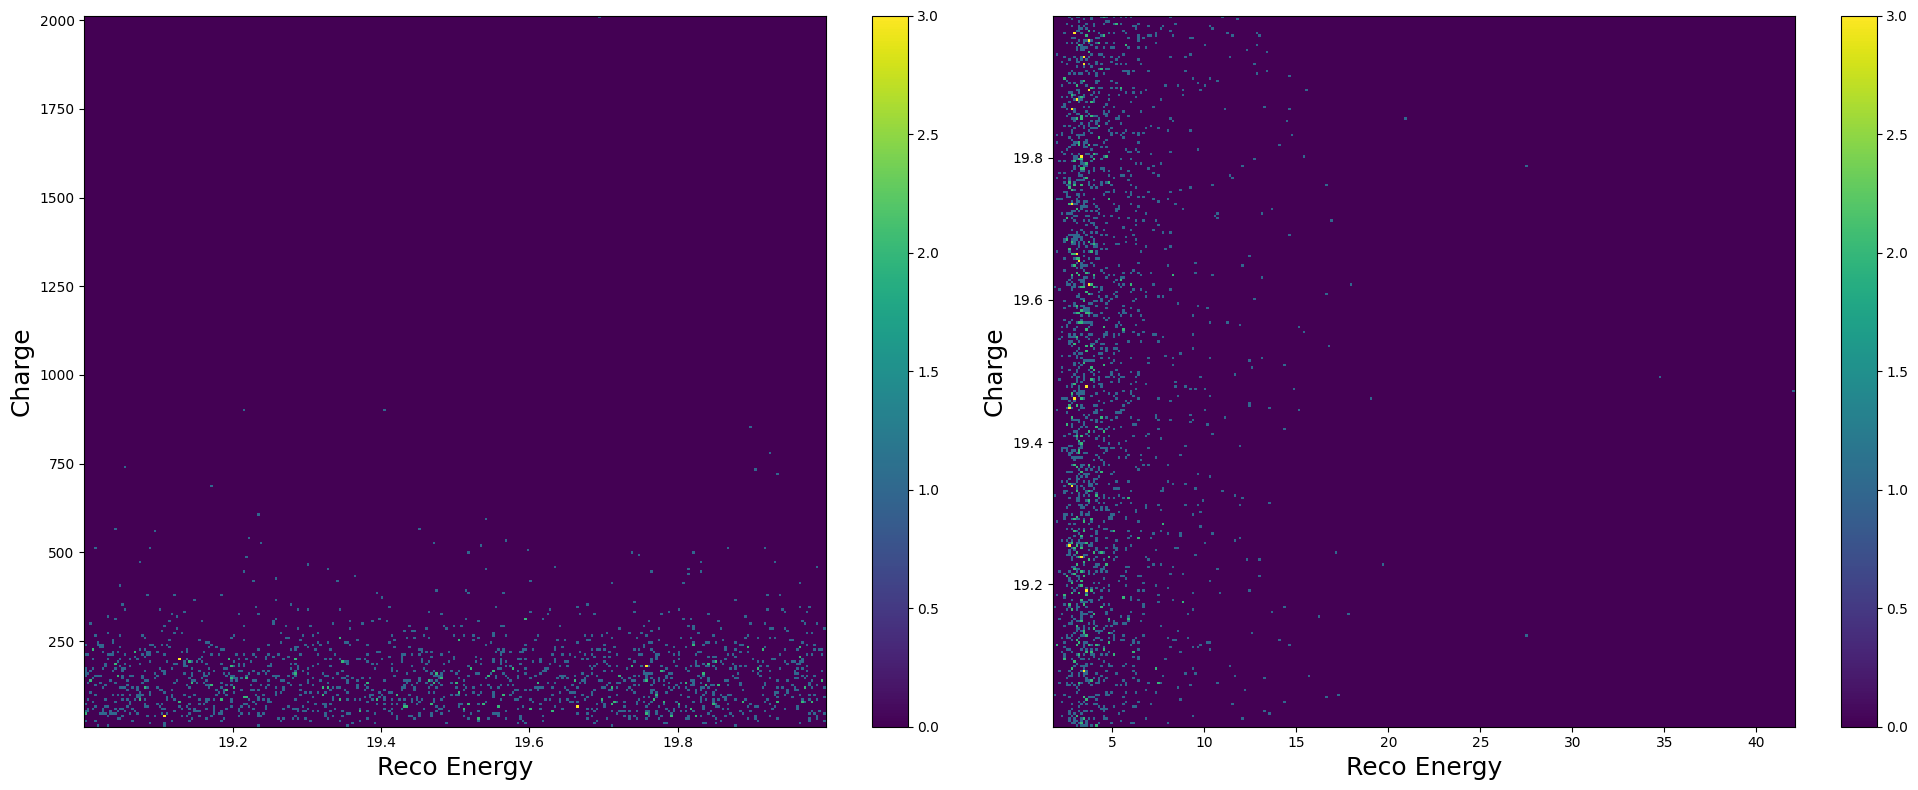

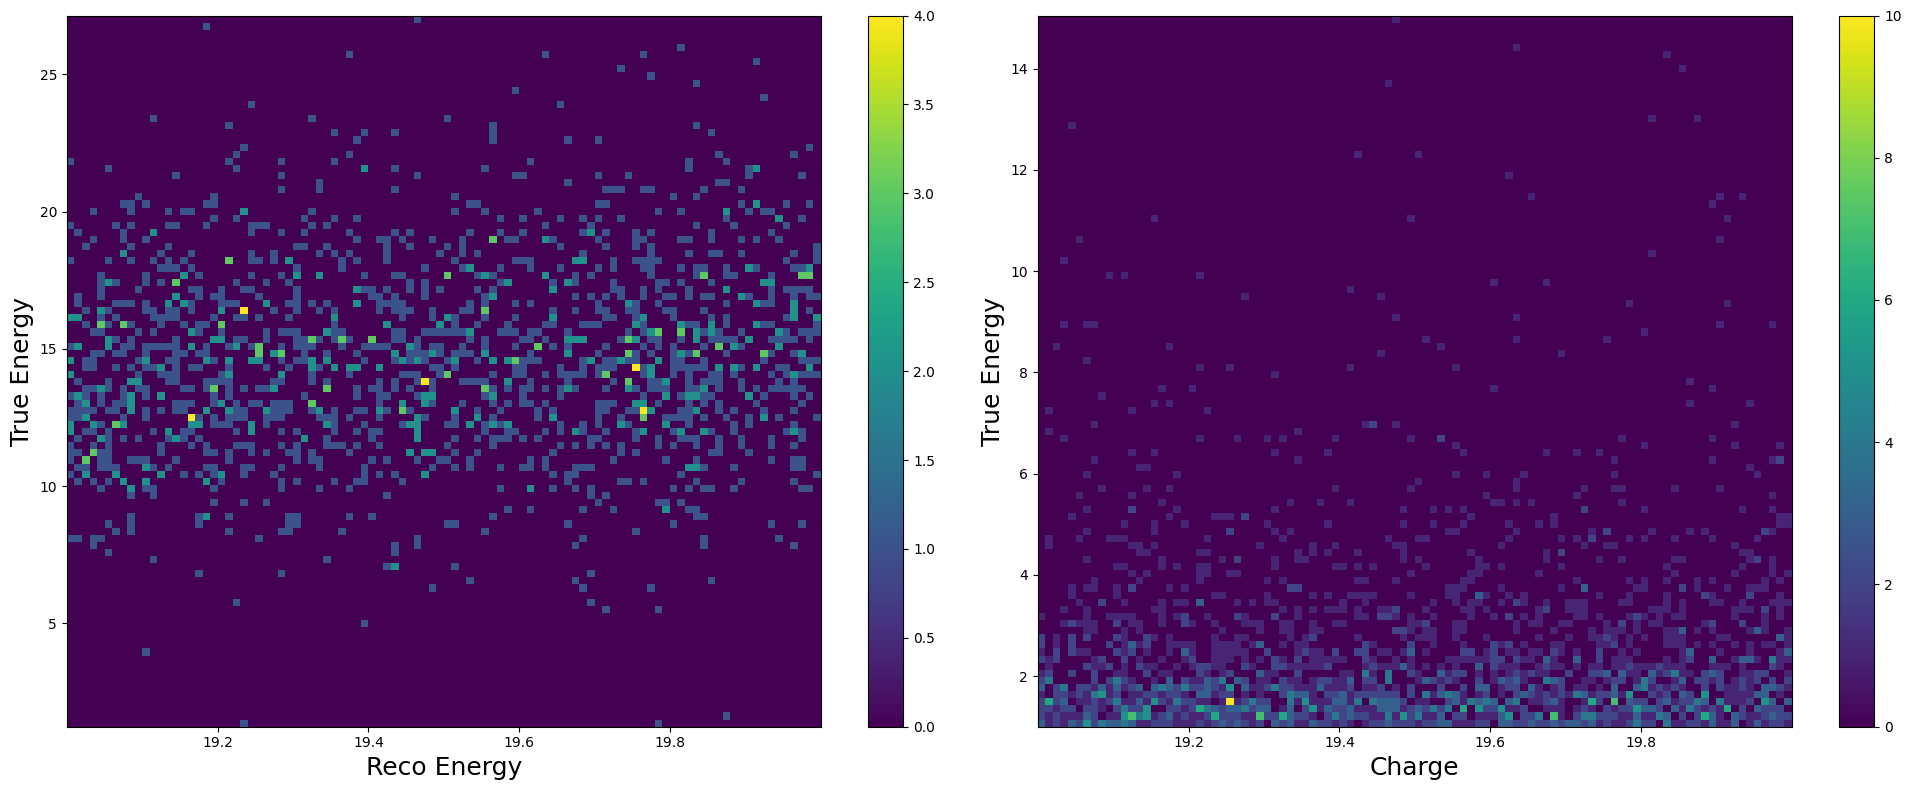

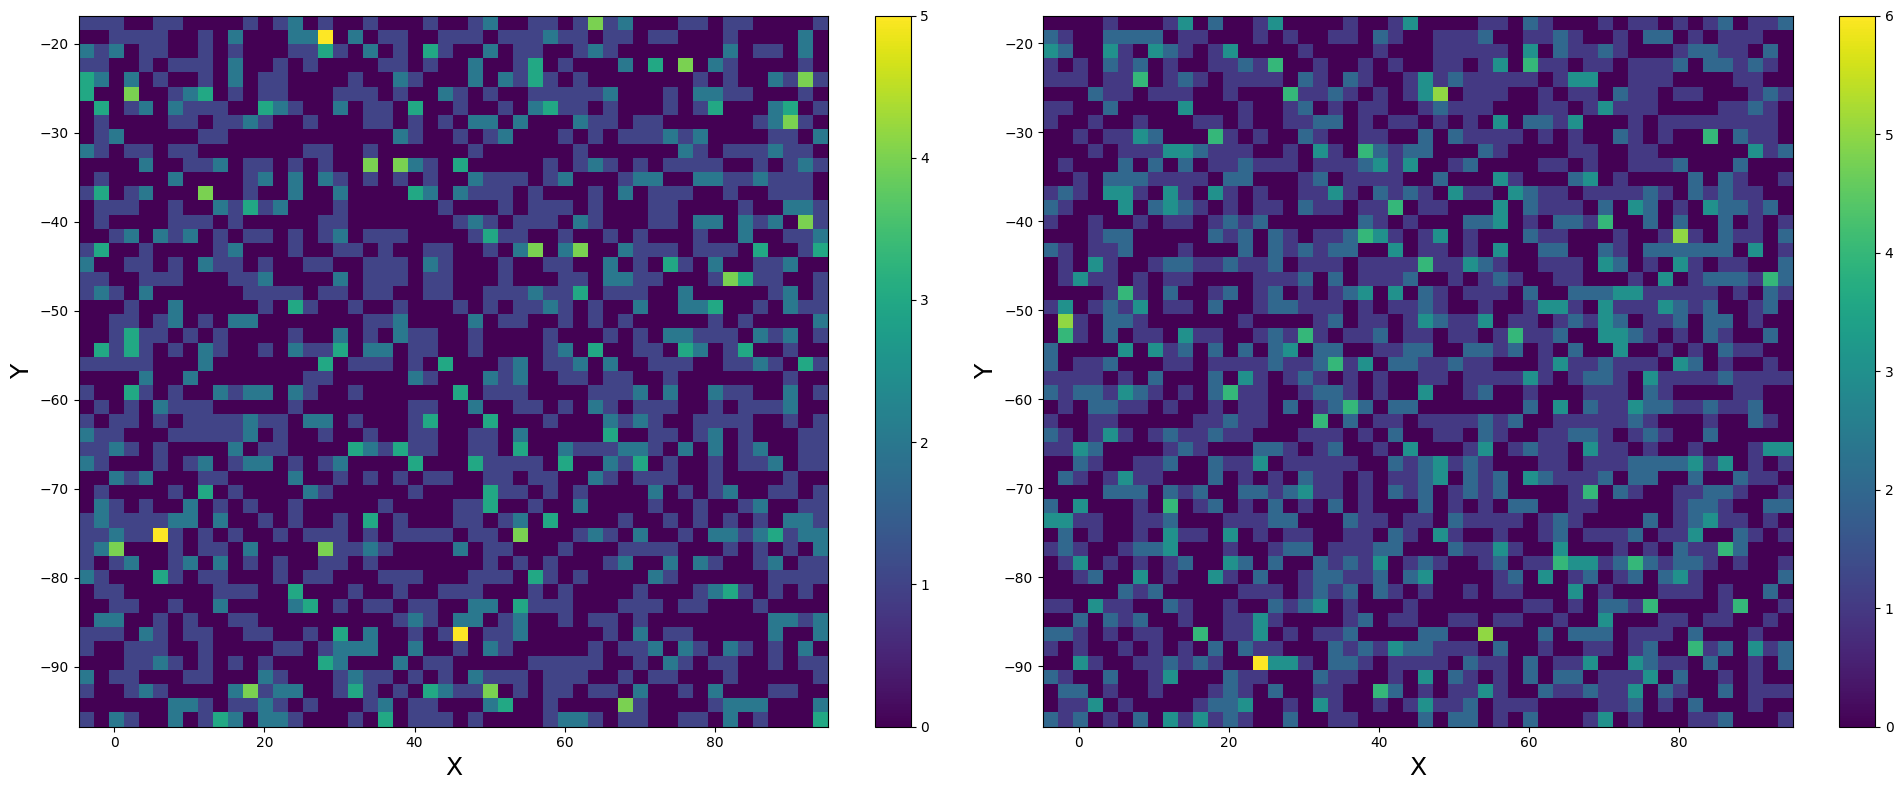

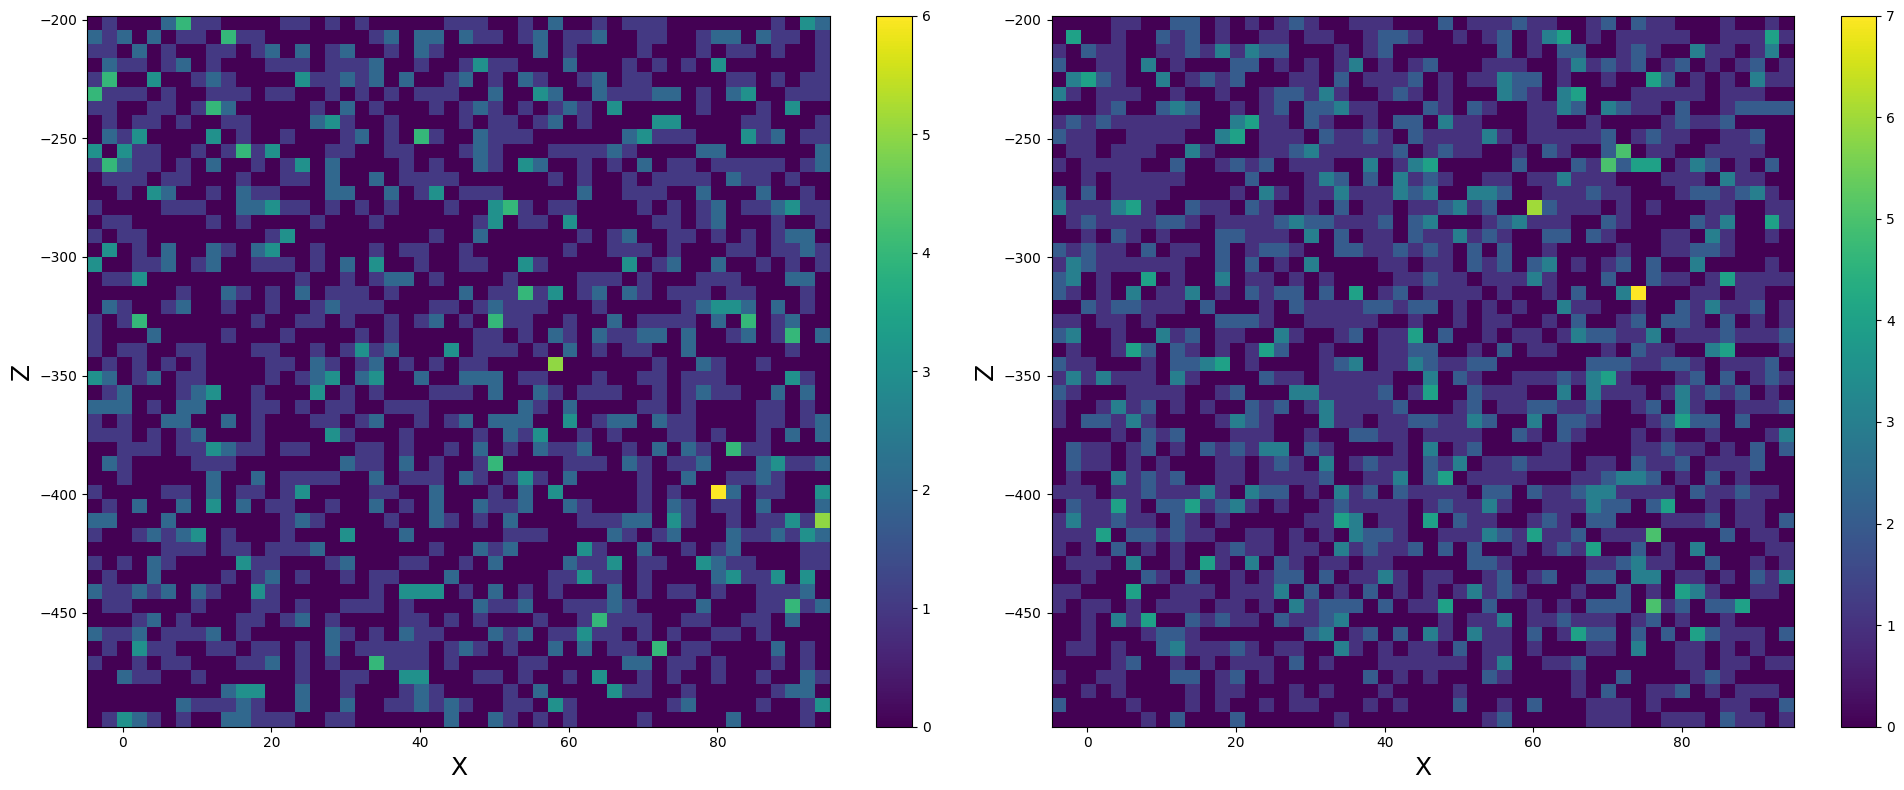

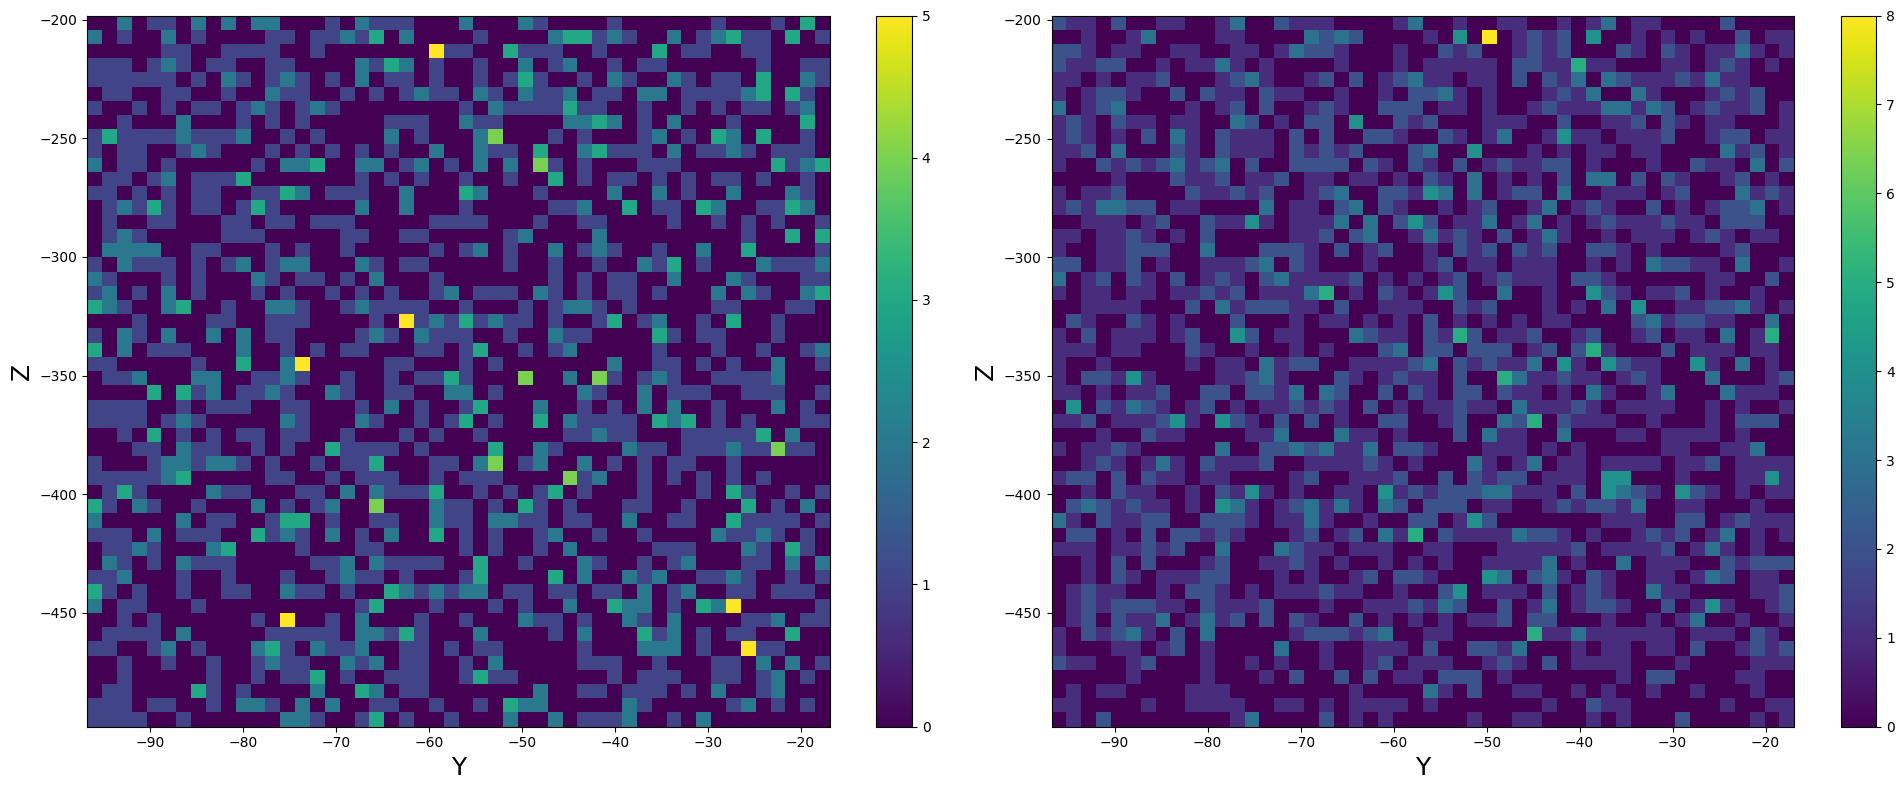

In [18]:
#energy cuts

emin = 19
emax = 20

energy_maskCC = (reco_energyCC >= emin) & (reco_energyCC <= emax)
energy_maskNC = (reco_energyNC >= emin) & (reco_energyNC <= emax)

charge_maskCC = (chargeCC >= emin) & (chargeCC <= emax)
charge_maskNC = (chargeNC >= emin) & (chargeNC <= emax)

fig, axs = plt.subplots(1, 2)
fig.set_figheight(8)
fig.set_figwidth(20)

a0 = axs[0].hist2d(reco_energyCC[energy_maskCC], chargeCC[energy_maskCC], bins=300)
fig.colorbar(a0[3], ax=axs[0])
axs[0].set_xlabel('Reco Energy', fontsize = 18)
axs[0].set_ylabel('Charge', fontsize = 18)

a1 = axs[1].hist2d(reco_energyCC[charge_maskCC], chargeCC[charge_maskCC], bins=300)
fig.colorbar(a1[3], ax=axs[1])
axs[1].set_xlabel('Reco Energy', fontsize = 18)
axs[1].set_ylabel('Charge', fontsize = 18)

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2)
fig.set_figheight(8)
fig.set_figwidth(20)

a0 = axs[0].hist2d(reco_energyCC[energy_maskCC], true_energyCC[energy_maskCC], bins=100)
fig.colorbar(a0[3], ax=axs[0])
axs[0].set_xlabel('Reco Energy', fontsize = 18)
axs[0].set_ylabel('True Energy', fontsize = 18)

a1 = axs[1].hist2d(chargeCC[charge_maskCC], true_energyCC[charge_maskCC], bins=100)
fig.colorbar(a1[3], ax=axs[1])
axs[1].set_xlabel('Charge', fontsize = 18)
axs[1].set_ylabel('True Energy', fontsize = 18)

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2)
fig.set_figheight(8)
fig.set_figwidth(20)

a0 = axs[0].hist2d(xCC[energy_maskCC], yCC[energy_maskCC], bins=50)
fig.colorbar(a0[3], ax=axs[0])
axs[0].set_xlabel('X', fontsize = 18)
axs[0].set_ylabel('Y', fontsize = 18)

a1 = axs[1].hist2d(xCC[charge_maskCC], yCC[charge_maskCC], bins=50)
fig.colorbar(a1[3], ax=axs[1])
axs[1].set_xlabel('X', fontsize = 18)
axs[1].set_ylabel('Y', fontsize = 18)

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2)
fig.set_figheight(8)
fig.set_figwidth(20)

a0 = axs[0].hist2d(xCC[energy_maskCC], zCC[energy_maskCC], bins=50)
fig.colorbar(a0[3], ax=axs[0])
axs[0].set_xlabel('X', fontsize = 18)
axs[0].set_ylabel('Z', fontsize = 18)

a1 = axs[1].hist2d(xCC[charge_maskCC], zCC[charge_maskCC], bins=50)
fig.colorbar(a1[3], ax=axs[1])
axs[1].set_xlabel('X', fontsize = 18)
axs[1].set_ylabel('Z', fontsize = 18)

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2)
fig.set_figheight(8)
fig.set_figwidth(20)

a0 = axs[0].hist2d(yCC[energy_maskCC], zCC[energy_maskCC], bins=50)
fig.colorbar(a0[3], ax=axs[0])
axs[0].set_xlabel('Y', fontsize = 18)
axs[0].set_ylabel('Z', fontsize = 18)

a1 = axs[1].hist2d(yCC[charge_maskCC], zCC[charge_maskCC], bins=50)
fig.colorbar(a1[3], ax=axs[1])
axs[1].set_xlabel('Y', fontsize = 18)
axs[1].set_ylabel('Z', fontsize = 18)

plt.tight_layout()
plt.show()

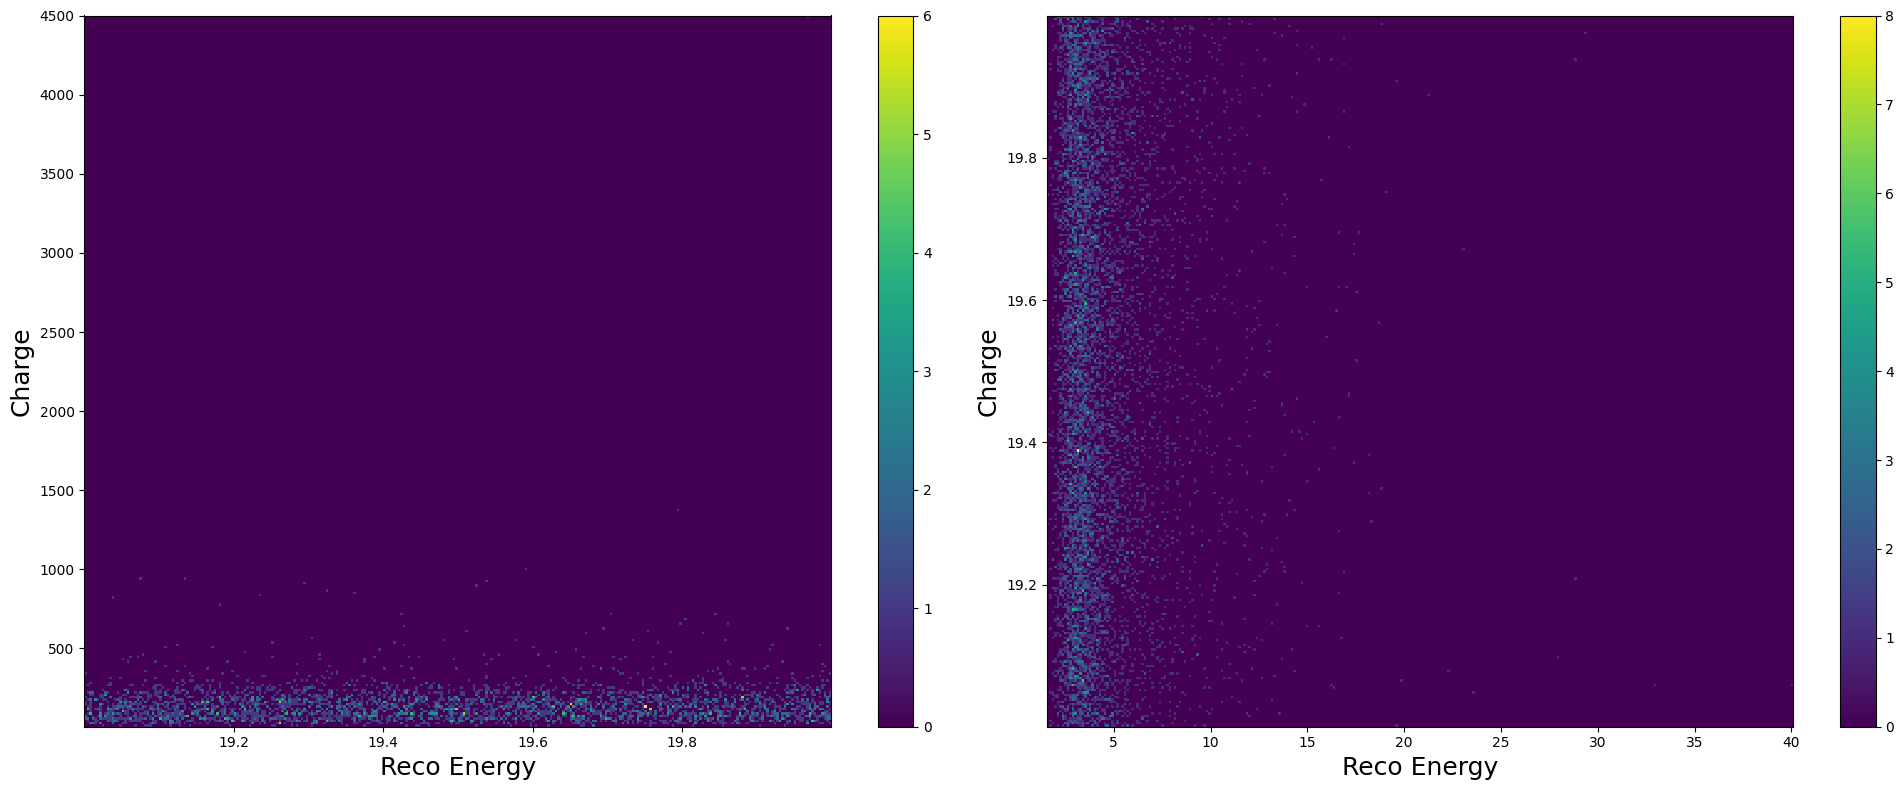

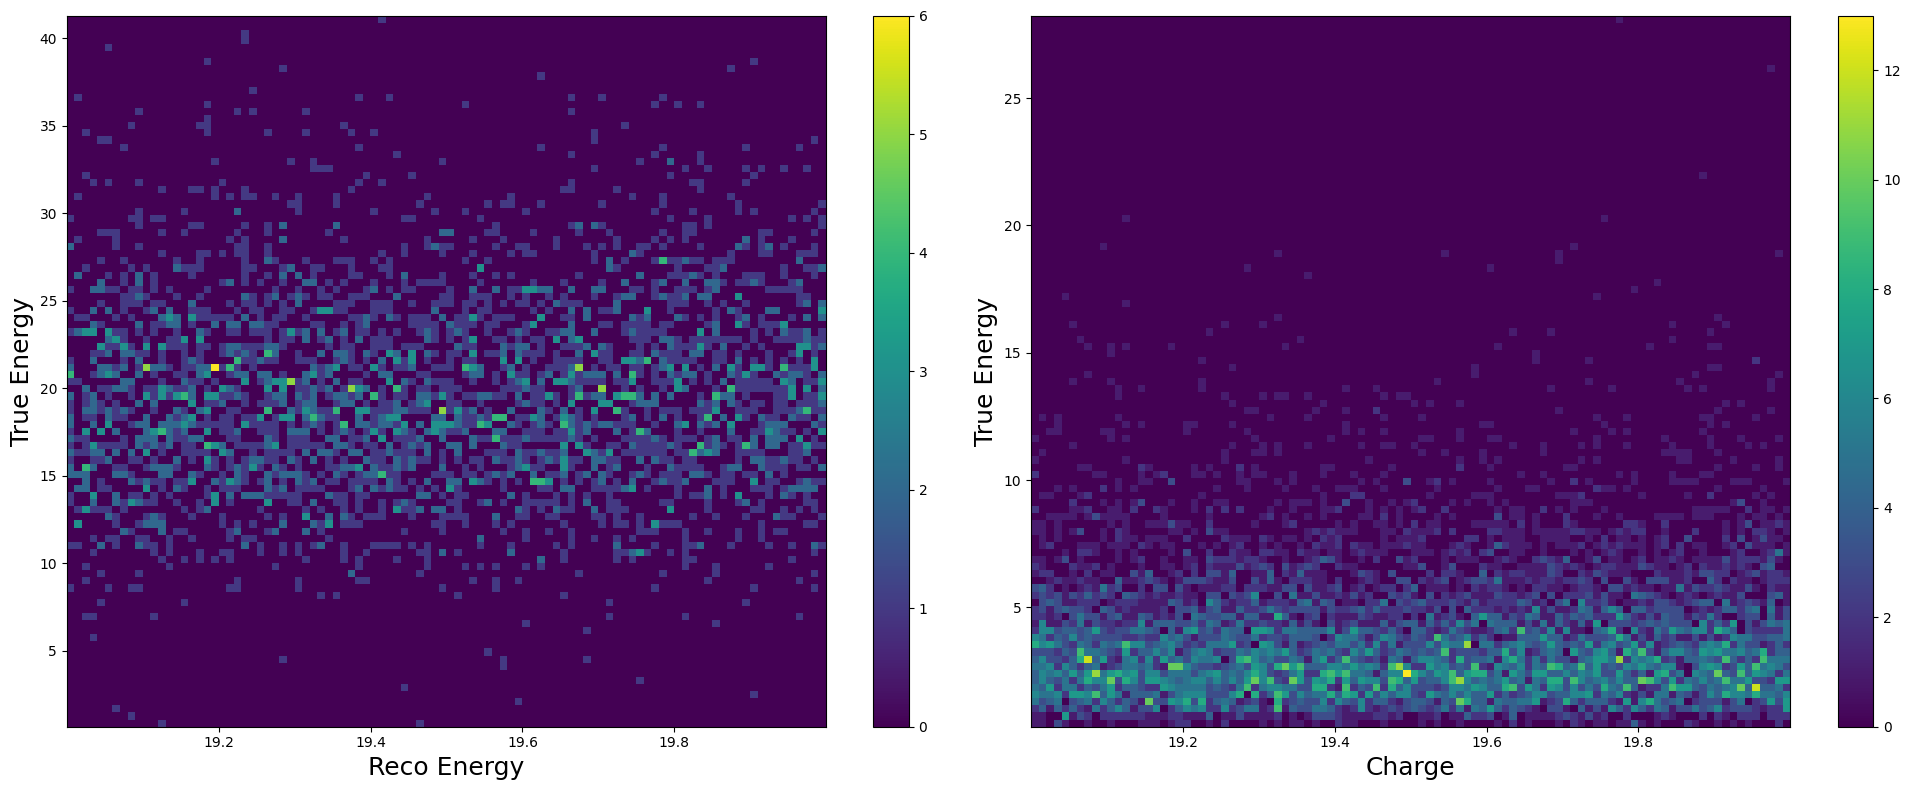

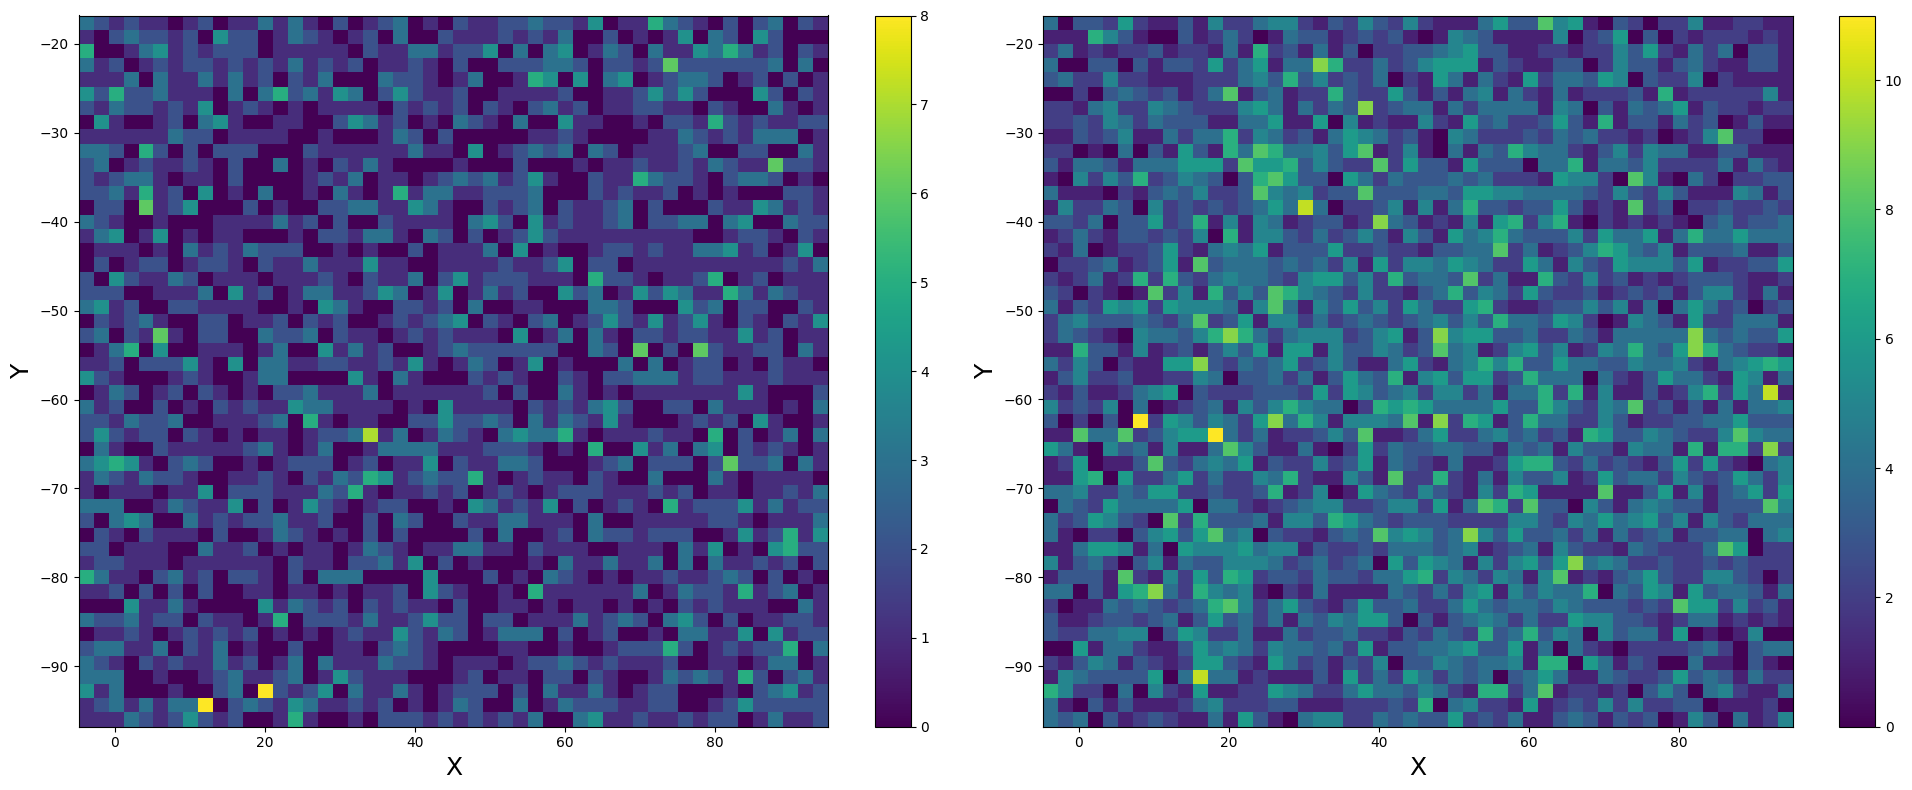

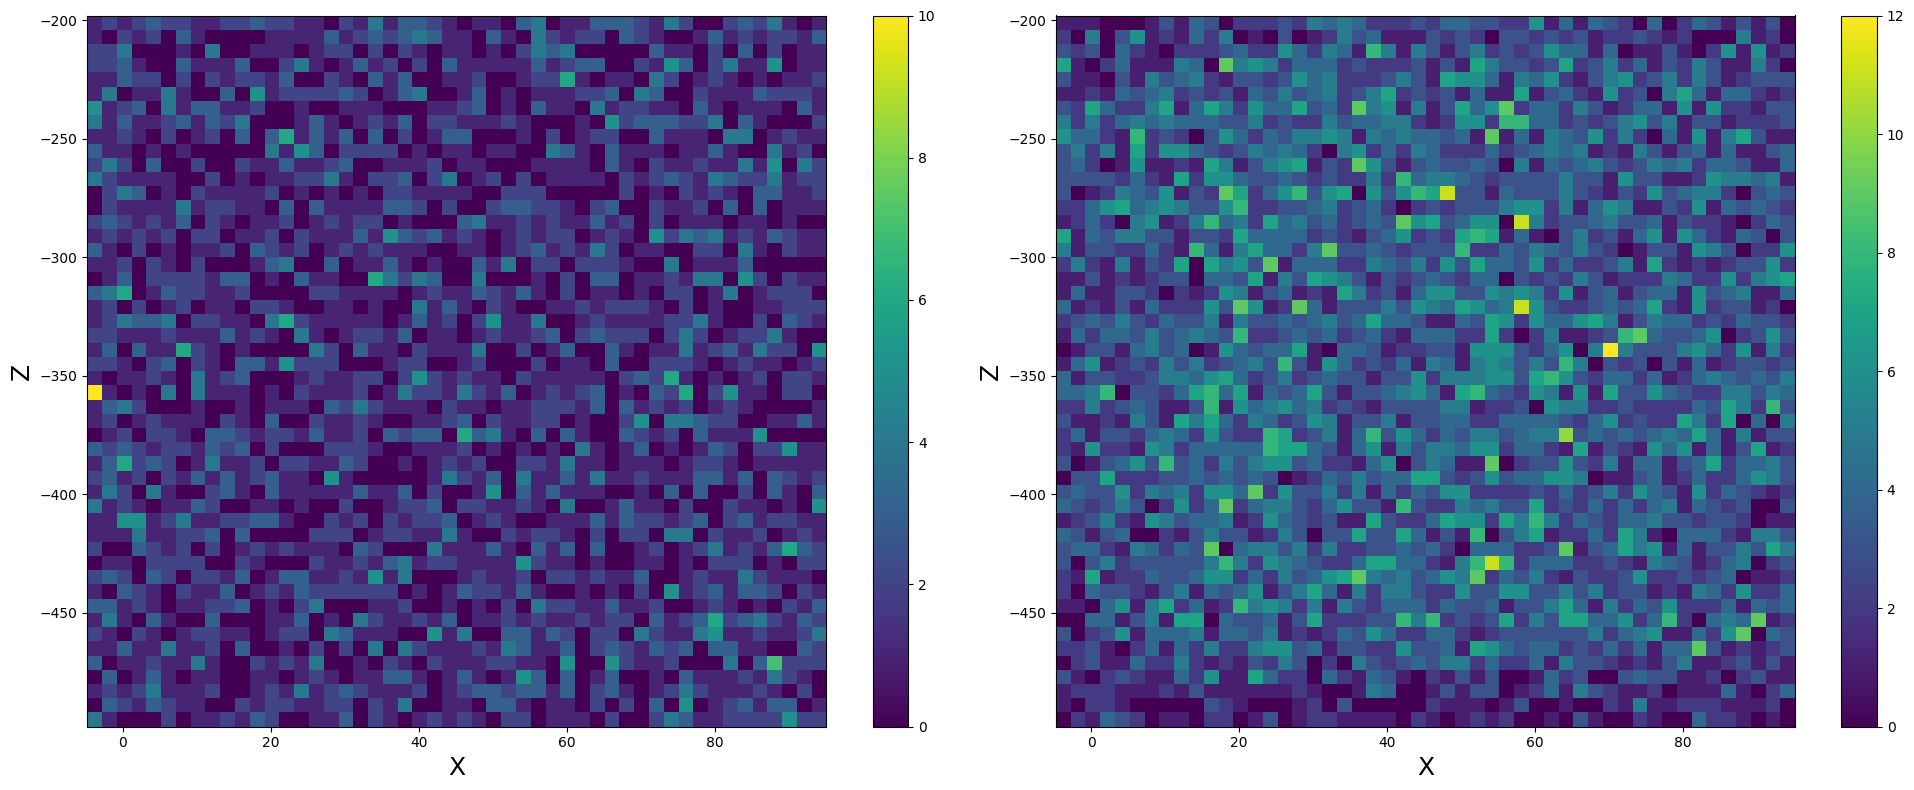

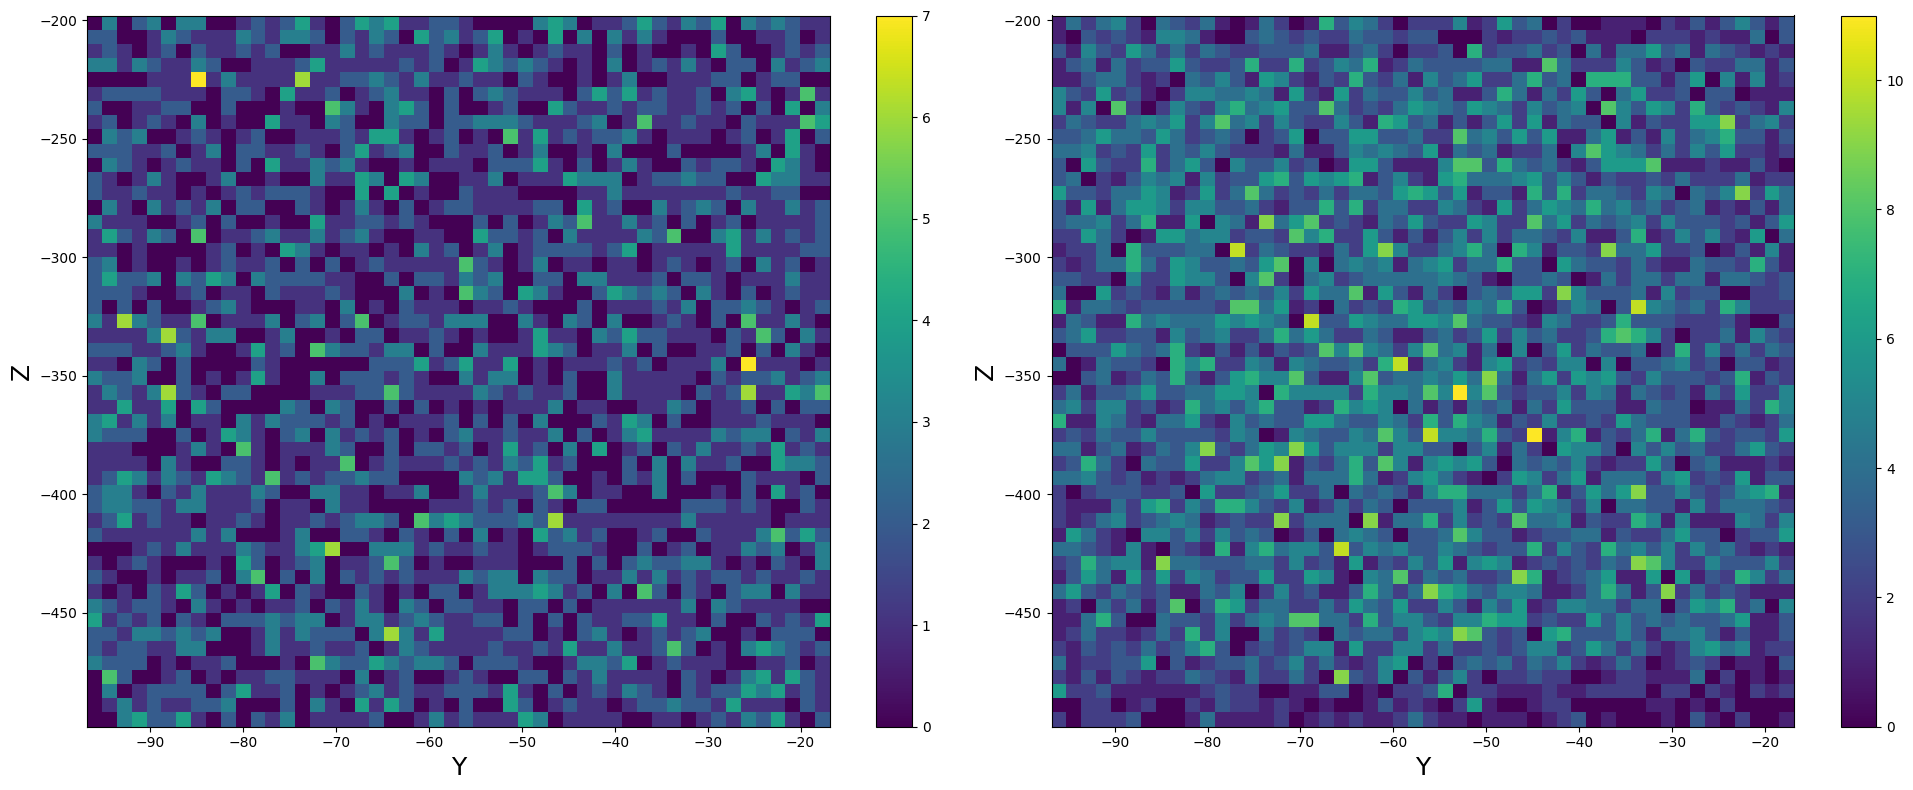

In [19]:
#energy cuts

emin = 19
emax = 20

energy_maskNC = (reco_energyNC >= emin) & (reco_energyNC <= emax)
energy_maskNC = (reco_energyNC >= emin) & (reco_energyNC <= emax)

charge_maskNC = (chargeNC >= emin) & (chargeNC <= emax)
charge_maskNC = (chargeNC >= emin) & (chargeNC <= emax)

fig, axs = plt.subplots(1, 2)
fig.set_figheight(8)
fig.set_figwidth(20)

a0 = axs[0].hist2d(reco_energyNC[energy_maskNC], chargeNC[energy_maskNC], bins=300)
fig.colorbar(a0[3], ax=axs[0])
axs[0].set_xlabel('Reco Energy', fontsize = 18)
axs[0].set_ylabel('Charge', fontsize = 18)

a1 = axs[1].hist2d(reco_energyNC[charge_maskNC], chargeNC[charge_maskNC], bins=300)
fig.colorbar(a1[3], ax=axs[1])
axs[1].set_xlabel('Reco Energy', fontsize = 18)
axs[1].set_ylabel('Charge', fontsize = 18)

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2)
fig.set_figheight(8)
fig.set_figwidth(20)

a0 = axs[0].hist2d(reco_energyNC[energy_maskNC], true_energyNC[energy_maskNC], bins=100)
fig.colorbar(a0[3], ax=axs[0])
axs[0].set_xlabel('Reco Energy', fontsize = 18)
axs[0].set_ylabel('True Energy', fontsize = 18)

a1 = axs[1].hist2d(chargeNC[charge_maskNC], true_energyNC[charge_maskNC], bins=100)
fig.colorbar(a1[3], ax=axs[1])
axs[1].set_xlabel('Charge', fontsize = 18)
axs[1].set_ylabel('True Energy', fontsize = 18)

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2)
fig.set_figheight(8)
fig.set_figwidth(20)

a0 = axs[0].hist2d(xNC[energy_maskNC], yNC[energy_maskNC], bins=50)
fig.colorbar(a0[3], ax=axs[0])
axs[0].set_xlabel('X', fontsize = 18)
axs[0].set_ylabel('Y', fontsize = 18)

a1 = axs[1].hist2d(xNC[charge_maskNC], yNC[charge_maskNC], bins=50)
fig.colorbar(a1[3], ax=axs[1])
axs[1].set_xlabel('X', fontsize = 18)
axs[1].set_ylabel('Y', fontsize = 18)

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2)
fig.set_figheight(8)
fig.set_figwidth(20)

a0 = axs[0].hist2d(xNC[energy_maskNC], zNC[energy_maskNC], bins=50)
fig.colorbar(a0[3], ax=axs[0])
axs[0].set_xlabel('X', fontsize = 18)
axs[0].set_ylabel('Z', fontsize = 18)

a1 = axs[1].hist2d(xNC[charge_maskNC], zNC[charge_maskNC], bins=50)
fig.colorbar(a1[3], ax=axs[1])
axs[1].set_xlabel('X', fontsize = 18)
axs[1].set_ylabel('Z', fontsize = 18)

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2)
fig.set_figheight(8)
fig.set_figwidth(20)

a0 = axs[0].hist2d(yNC[energy_maskNC], zNC[energy_maskNC], bins=50)
fig.colorbar(a0[3], ax=axs[0])
axs[0].set_xlabel('Y', fontsize = 18)
axs[0].set_ylabel('Z', fontsize = 18)

a1 = axs[1].hist2d(yNC[charge_maskNC], zNC[charge_maskNC], bins=50)
fig.colorbar(a1[3], ax=axs[1])
axs[1].set_xlabel('Y', fontsize = 18)
axs[1].set_ylabel('Z', fontsize = 18)

plt.tight_layout()
plt.show()